## A character-level implementation of [Bengio et al. 2003](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf)

In their original paper they associate each of 17,000 <span style="color:red">words</span> with a 30-dimensional vector (called feature vector).

This is a concept of (vector) embedding of words.

这些 associations 被存放在了一个 lookup table 里：一个 17000 * 30 的矩阵。

In the beginning, all the points (i.e., the feature vectors of the words) in this 30-dimensional space are initialized randomly, so they are spread out into all directions in this space. Then using backpropagation those feature vectors are tuned So that words with similar meaning move close together, and words that are semantically different are pointing in different directions in this (semantic) space.

They <span style="color:red">maximize the log likelihood</span> to train the multi-layer neural network.

During test time, prefix could be a sequence that never appears in the training set. 但 prefix 中的很多 tokens 在 semantic space 里和 neural network 见过的很多 tokens 离得很近。<span style="color:red">Neural network 大概知道这些它见过的 tokens 后面的 prediction 是什么</span>，所以 neural network 就能对这个没见过的 sequence 给出一个相似的 prediction。

In [85]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

### Vocabulary & Mappings to/from indices

In [4]:
letters = sorted(list(set(''.join(words))))
str_to_idx = {s:i+1 for i, s in enumerate(letters)}
str_to_idx['.'] = 0
idx_to_str = {i:s for s, i in str_to_idx.items()}

print(idx_to_str)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


### Build the Dataset

In [5]:
block_size = 3  # size of the prefix context
X = []  # inputs
Y = []  # labels

for w in words[:2]:
    print(w)
    context = [0] * block_size  # [0,0,...,0]
    # Note here that we use the special token '.' for padding
    for ch in w + '.':
        index = str_to_idx[ch]
        X.append(context)
        Y.append(index)

        print(''.join(idx_to_str[i] for i in context), '--->', idx_to_str[index])

        context = context[1:] + [index]   # roll the window

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .


In [6]:
X.shape, X.dtype

(torch.Size([12, 3]), torch.int64)

In [7]:
Y.shape, Y.dtype

(torch.Size([12]), torch.int64)

原论文有17,000个词汇，而我们有27个词汇（26 个英文字母 + 一个 special token）。

原论文用了30个维度去 embed 那17,000个词汇。

<span style="color:red">我们只需要用2个维度去 embed 这27个词汇。</span>

In [8]:
M = torch.randn((27, 2))
M


tensor([[ 0.5159, -0.1623],
        [-0.3783, -0.6737],
        [-0.4347,  0.7063],
        [-0.5004, -0.4983],
        [ 0.0363,  1.3368],
        [-0.5198, -1.7780],
        [-0.6475, -0.0252],
        [-1.0047,  1.2971],
        [ 0.9651, -0.5398],
        [-0.4942,  2.6959],
        [ 0.2525, -0.9576],
        [ 1.3152,  0.5391],
        [-0.6649,  0.3578],
        [ 0.2996,  0.3551],
        [-0.1519,  1.3300],
        [-0.4467,  0.5612],
        [ 1.1433, -0.7337],
        [ 1.1562, -0.9785],
        [-0.8872, -0.8892],
        [ 0.8145, -0.0915],
        [ 0.4351, -1.4965],
        [ 0.9533,  0.8784],
        [ 1.0710, -2.0257],
        [-0.2849,  0.9596],
        [ 0.0733, -0.7699],
        [ 0.8593, -0.7264],
        [ 0.2163,  0.5092]])

我们可以用 one-hot vector 去提取某个词的 vector embedding:

In [9]:
M.dtype

torch.float32

In [10]:
F.one_hot(torch.tensor(5), num_classes=27).dtype

torch.int64

In [11]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ M

tensor([-0.5198, -1.7780])

这里我们可以把“从embedding matrix M中提取token对应的embedded vector”理解成“用one hot encoding去表示输入tokens，然后把这些encoding（拼成一个input）feed进一个bias为 0 的linear layer里（这个layer中有embedding dimension * block_size个神经元，每个神经元有 vocabulary size * block_size 个weights），这个 linear layer 的输出就是这些 tokens 的 embedded vectors”

我们当然可以直接从embedding matrix M中取：

In [12]:
M[5]

tensor([-0.5198, -1.7780])

We can also do:

In [13]:
M[torch.tensor([5,5,5])]

tensor([[-0.5198, -1.7780],
        [-0.5198, -1.7780],
        [-0.5198, -1.7780]])

Recall:

In [14]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1]])

If we do:

In [15]:
M[X]

tensor([[[ 0.5159, -0.1623],
         [ 0.5159, -0.1623],
         [ 0.5159, -0.1623]],

        [[ 0.5159, -0.1623],
         [ 0.5159, -0.1623],
         [-0.5198, -1.7780]],

        [[ 0.5159, -0.1623],
         [-0.5198, -1.7780],
         [ 0.2996,  0.3551]],

        [[-0.5198, -1.7780],
         [ 0.2996,  0.3551],
         [ 0.2996,  0.3551]],

        [[ 0.2996,  0.3551],
         [ 0.2996,  0.3551],
         [-0.3783, -0.6737]],

        [[ 0.5159, -0.1623],
         [ 0.5159, -0.1623],
         [ 0.5159, -0.1623]],

        [[ 0.5159, -0.1623],
         [ 0.5159, -0.1623],
         [-0.4467,  0.5612]],

        [[ 0.5159, -0.1623],
         [-0.4467,  0.5612],
         [-0.6649,  0.3578]],

        [[-0.4467,  0.5612],
         [-0.6649,  0.3578],
         [-0.4942,  2.6959]],

        [[-0.6649,  0.3578],
         [-0.4942,  2.6959],
         [ 1.0710, -2.0257]],

        [[-0.4942,  2.6959],
         [ 1.0710, -2.0257],
         [-0.4942,  2.6959]],

        [[ 1.0710, -2

In [16]:
M[X].shape

torch.Size([12, 3, 2])

意为：对X每个元素取M对应的行

例如：

In [17]:
M[X][1,2]

tensor([-0.5198, -1.7780])

In [18]:
X[1,2]

tensor(5)

In [19]:
M[5]

tensor([-0.5198, -1.7780])

因此，`M[X]` embed 了 `X` 中所有的 token

In [20]:
emb_X = M[X]

In [21]:
emb_X[:,0,:]   # 所有 training examples 的 prefix context 中第一个 token 的 embedded vector

tensor([[ 0.5159, -0.1623],
        [ 0.5159, -0.1623],
        [ 0.5159, -0.1623],
        [-0.5198, -1.7780],
        [ 0.2996,  0.3551],
        [ 0.5159, -0.1623],
        [ 0.5159, -0.1623],
        [ 0.5159, -0.1623],
        [-0.4467,  0.5612],
        [-0.6649,  0.3578],
        [-0.4942,  2.6959],
        [ 1.0710, -2.0257]])

In [22]:
emb_X[:,0,:].shape

torch.Size([12, 2])

我们可以把input拼起来：

In [23]:
torch.cat([emb_X[:,0,:], emb_X[:,1,:], emb_X[:,2,:]], dim=1)

tensor([[ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.5198, -1.7780],
        [ 0.5159, -0.1623, -0.5198, -1.7780,  0.2996,  0.3551],
        [-0.5198, -1.7780,  0.2996,  0.3551,  0.2996,  0.3551],
        [ 0.2996,  0.3551,  0.2996,  0.3551, -0.3783, -0.6737],
        [ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.4467,  0.5612],
        [ 0.5159, -0.1623, -0.4467,  0.5612, -0.6649,  0.3578],
        [-0.4467,  0.5612, -0.6649,  0.3578, -0.4942,  2.6959],
        [-0.6649,  0.3578, -0.4942,  2.6959,  1.0710, -2.0257],
        [-0.4942,  2.6959,  1.0710, -2.0257, -0.4942,  2.6959],
        [ 1.0710, -2.0257, -0.4942,  2.6959, -0.3783, -0.6737]])

An equivalent but scalable way to do this:

In [24]:
torch.cat(torch.unbind(emb_X, dim=1), dim=1)

tensor([[ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.5198, -1.7780],
        [ 0.5159, -0.1623, -0.5198, -1.7780,  0.2996,  0.3551],
        [-0.5198, -1.7780,  0.2996,  0.3551,  0.2996,  0.3551],
        [ 0.2996,  0.3551,  0.2996,  0.3551, -0.3783, -0.6737],
        [ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.4467,  0.5612],
        [ 0.5159, -0.1623, -0.4467,  0.5612, -0.6649,  0.3578],
        [-0.4467,  0.5612, -0.6649,  0.3578, -0.4942,  2.6959],
        [-0.6649,  0.3578, -0.4942,  2.6959,  1.0710, -2.0257],
        [-0.4942,  2.6959,  1.0710, -2.0257, -0.4942,  2.6959],
        [ 1.0710, -2.0257, -0.4942,  2.6959, -0.3783, -0.6737]])

`torch.unbind(emb, dim)` 把 `emb` 沿其第dim个维度拆开铺成一个tuple。

Pytorch tensor在内存上永远是一维数列，但 there are extra layer of logic on how the data in the tensor can be retrieved:

In [25]:
a = torch.arange(18)
print(a)
print(a.shape)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])
torch.Size([18])


In [26]:
a.view(3,3,2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

`view` does not change the underlying storage of the tensor.

In [27]:
b = a.view(2,9)
print(b)
print(b.shape)

tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17]])
torch.Size([2, 9])


In [28]:
b.storage()

C:\Users\xiaoy\AppData\Local\Temp\ipykernel_22428\3076968323.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  b.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

More on this: see [PyTorch internals](https://blog.ezyang.com/2019/05/pytorch-internals/)

我们可以用 `view` 去高效地把input拼出来：

In [29]:
emb_X.shape

torch.Size([12, 3, 2])

In [30]:
emb_X.view(emb_X.shape[0],6)

tensor([[ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.5198, -1.7780],
        [ 0.5159, -0.1623, -0.5198, -1.7780,  0.2996,  0.3551],
        [-0.5198, -1.7780,  0.2996,  0.3551,  0.2996,  0.3551],
        [ 0.2996,  0.3551,  0.2996,  0.3551, -0.3783, -0.6737],
        [ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.4467,  0.5612],
        [ 0.5159, -0.1623, -0.4467,  0.5612, -0.6649,  0.3578],
        [-0.4467,  0.5612, -0.6649,  0.3578, -0.4942,  2.6959],
        [-0.6649,  0.3578, -0.4942,  2.6959,  1.0710, -2.0257],
        [-0.4942,  2.6959,  1.0710, -2.0257, -0.4942,  2.6959],
        [ 1.0710, -2.0257, -0.4942,  2.6959, -0.3783, -0.6737]])

Equivalently:

In [31]:
emb_X.view(-1,6)   # -1 == lets pytorch infer

tensor([[ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.5198, -1.7780],
        [ 0.5159, -0.1623, -0.5198, -1.7780,  0.2996,  0.3551],
        [-0.5198, -1.7780,  0.2996,  0.3551,  0.2996,  0.3551],
        [ 0.2996,  0.3551,  0.2996,  0.3551, -0.3783, -0.6737],
        [ 0.5159, -0.1623,  0.5159, -0.1623,  0.5159, -0.1623],
        [ 0.5159, -0.1623,  0.5159, -0.1623, -0.4467,  0.5612],
        [ 0.5159, -0.1623, -0.4467,  0.5612, -0.6649,  0.3578],
        [-0.4467,  0.5612, -0.6649,  0.3578, -0.4942,  2.6959],
        [-0.6649,  0.3578, -0.4942,  2.6959,  1.0710, -2.0257],
        [-0.4942,  2.6959,  1.0710, -2.0257, -0.4942,  2.6959],
        [ 1.0710, -2.0257, -0.4942,  2.6959, -0.3783, -0.6737]])

### Input Layer

In [32]:
inputs = emb_X.view(-1,6)

### Hidden Layer

In [33]:
num_neuron_hidden = 100   # number of neurons in the hidden layer
vector_embedding_dim = 2
num_prefix_context_token = 3

num_input = vector_embedding_dim * num_prefix_context_token

In [34]:
W_hidden = torch.randn((num_input, num_neuron_hidden))
b_hidden = torch.randn(100)

In [35]:
hidden_out = torch.tanh(inputs @ W_hidden + b_hidden)   # Note that b1 is broadcasted here
hidden_out

tensor([[ 0.3623,  0.6216,  0.2906,  ...,  0.2710, -0.8652, -0.8757],
        [ 0.9690,  0.9625,  0.9442,  ...,  0.8850, -0.7642,  0.9344],
        [ 0.9813,  0.4045, -0.9899,  ...,  0.9958, -0.9912, -0.9554],
        ...,
        [ 0.2859,  1.0000,  0.9960,  ...,  0.9580,  0.8487, -0.7265],
        [-0.9100, -1.0000, -0.9674,  ..., -0.5618,  0.1913, -0.9814],
        [ 0.8016,  0.9997,  0.9729,  ..., -0.9497, -0.5459, -0.6391]])

### Output Layer

In [36]:
W_output = torch.randn((num_neuron_hidden, 27))
b_output = torch.randn(27)

In [37]:
logits = hidden_out @ W_output + b_output
logits

tensor([[  4.2611, -14.5398,   4.1018,   3.7878,  15.8036,   3.9631,   5.5340,
          10.7434,  -6.8827,  12.7501,   0.4528,  -7.1476,  -8.3614, -15.6228,
           8.1518, -11.3431,   8.1054,   6.3674,  11.0605,   4.6174,  -1.4227,
           3.2307,  -6.5664,   7.3399,   3.8135, -14.6956,  -6.1079],
        [  3.4502,   2.0961,   3.1532,  -3.9024,   5.3366,   9.4326,   5.5709,
          -2.1307,  -7.7618,   1.7020,  -3.4864, -12.0165, -13.7746,  10.9790,
           4.6467,   4.5498,   5.8772,   4.9657,  10.4158,  -7.5862,   4.4455,
           0.0944,  -1.4662,   1.1802,   1.9706, -21.2080,  -1.6428],
        [-10.9960, -19.9258,   0.1817,  -4.1183,   5.6401,  -6.2678,   5.1952,
           8.0581, -18.8196,  -0.9885,  -3.4182,  -7.2786,   2.5443,  -5.5552,
         -12.0513, -21.6341,   8.1671,   5.6723,   5.6703,   1.8365,  -0.4796,
           4.1425,  14.1337,   6.1875,  13.7617,  -1.9065, -13.9526],
        [  0.7961,  -1.8612,  -4.0040,  -8.5465,   9.6372,  -6.3412,  -0.8697,


### Softmax

In [38]:
counts = logits.exp()
counts

tensor([[7.0890e+01, 4.8468e-07, 6.0448e+01, 4.4158e+01, 7.3016e+06, 5.2621e+01,
         2.5314e+02, 4.6323e+04, 1.0253e-03, 3.4457e+05, 1.5728e+00, 7.8676e-04,
         2.3372e-04, 1.6409e-07, 3.4695e+03, 1.1851e-05, 3.3123e+03, 5.8256e+02,
         6.3607e+04, 1.0123e+02, 2.4105e-01, 2.5296e+01, 1.4068e-03, 1.5405e+03,
         4.5308e+01, 4.1474e-07, 2.2252e-03],
        [3.1506e+01, 8.1343e+00, 2.3412e+01, 2.0193e-02, 2.0780e+02, 1.2489e+04,
         2.6268e+02, 1.1875e-01, 4.2567e-04, 5.4851e+00, 3.0612e-02, 6.0439e-06,
         1.0418e-06, 5.8630e+04, 1.0424e+02, 9.4611e+01, 3.5680e+02, 1.4341e+02,
         3.3381e+04, 5.0741e-04, 8.5244e+01, 1.0990e+00, 2.3081e-01, 3.2550e+00,
         7.1749e+00, 6.1587e-10, 1.9343e-01],
        [1.6768e-05, 2.2199e-09, 1.1993e+00, 1.6273e-02, 2.8148e+02, 1.8964e-03,
         1.8040e+02, 3.1593e+03, 6.7102e-09, 3.7213e-01, 3.2771e-02, 6.9012e-04,
         1.2734e+01, 3.8674e-03, 5.8373e-06, 4.0218e-10, 3.5230e+03, 2.9070e+02,
         2.9013e+

In [39]:
prob = counts / counts.sum(1, keepdim=True)

沿 dim=1（27 个字符那个维度）求和，keepdim=True 让结果保持 (N, 1) 而不是 (N,)

(N, 27) / (N, 1) 触发 broadcasting：那一列和被横向复制 27 份，于是每一行除以自己那一行的总和

In [40]:
print(prob.shape)
print(prob[0].sum())

torch.Size([12, 27])
tensor(1.)


### Mean NLL Loss

In [41]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0])

In [42]:
prob[torch.arange(prob.shape[0]), Y]

tensor([6.7761e-06, 5.5397e-01, 1.6595e-09, 9.2857e-11, 1.4061e-05, 1.5261e-12,
        9.4218e-06, 2.6609e-05, 3.1991e-08, 1.1487e-05, 1.4196e-20, 1.1188e-04])

In [43]:
prob[torch.arange(prob.shape[0]), Y].log()

tensor([-11.9021,  -0.5906, -20.2168, -23.1000, -11.1721, -27.2083, -11.5725,
        -10.5343, -17.2578, -11.3743, -45.7013,  -9.0980])

In [44]:
nll_loss = -(prob[torch.arange(prob.shape[0]), Y].log().mean())
nll_loss

tensor(16.6440)

Negative Log Likelihood is also called Cross Entropy:

In [45]:
F.cross_entropy(logits, Y)

tensor(16.6440)

`cross_entropy`'s implementation is much more efficient (due to that 1. for forward pass it uses <span style="color:red">fused kernel that clusters mathematical operations</span>, 2. for backward pass it is implemented with mathematical expressions that are simplifed analytically) and numerically stable (by offseting logits by their maximum, which does not change the probability computed. Note that if a logit is big during optimization, exp it will cause `inf` in program).

### Minibatch

For each step, instead of calculating the loss for the entire dataset (which is slow per step), we can calculate the loss for a small random subset (faster per step). By doing so, <span style="color:red">the gradient computed will be an estimation of the gradient for the full set</span>.

A small minibatch could be served as a good approximation of the full gradient, and thus using minibatches to optimize for more steps rather than using full batches to optimize for fewer steps yields better results.

### Determine a good learning rate

In [54]:
# Full Dataset:

block_size = 3  # size of the prefix context
X = []  # inputs
Y = []  # labels

for w in words:
    context = [0] * block_size  # [0,0,...,0]
    # Note here that we use the special token '.' for padding
    for ch in w + '.':
        index = str_to_idx[ch]
        X.append(context)
        Y.append(index)
        context = context[1:] + [index]   # roll the window

X = torch.tensor(X)
Y = torch.tensor(Y)

X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

We can first estimate the reasonable boundary of the learning rate by running fresh trainings.

In [69]:
minibatch_size = 32
num_step = 100
learning_rate = 0.001

M = torch.randn((27,2))
W_hidden = torch.randn((6,100))
b_hidden = torch.randn(100)
W_output = torch.randn((100, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

for _ in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X.shape[0], (minibatch_size,))

    # forward pass:
    emb_X_mini = M[X[ix]]
    hidden_out_mini = torch.tanh(emb_X_mini.view(-1,6) @ W_hidden + b_hidden)
    logits_mini = hidden_out_mini @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits_mini, Y[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

    with torch.no_grad():
        emb_X = M[X]
        hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
        logits = hidden_out @ W_output + b_output
        loss_full = F.cross_entropy(logits, Y)
        print('Full Loss:', loss_full.item())

Full Loss: 18.54863739013672
Full Loss: 18.532468795776367
Full Loss: 18.516359329223633
Full Loss: 18.503076553344727
Full Loss: 18.49184226989746
Full Loss: 18.476839065551758
Full Loss: 18.463668823242188
Full Loss: 18.44843864440918
Full Loss: 18.43571662902832
Full Loss: 18.42307472229004
Full Loss: 18.411760330200195
Full Loss: 18.398160934448242
Full Loss: 18.383602142333984
Full Loss: 18.369508743286133
Full Loss: 18.353788375854492
Full Loss: 18.34268569946289
Full Loss: 18.330434799194336
Full Loss: 18.317501068115234
Full Loss: 18.307018280029297
Full Loss: 18.29355812072754
Full Loss: 18.275297164916992
Full Loss: 18.260818481445312
Full Loss: 18.248516082763672
Full Loss: 18.23540687561035
Full Loss: 18.224458694458008
Full Loss: 18.211875915527344
Full Loss: 18.200300216674805
Full Loss: 18.188783645629883
Full Loss: 18.17847442626953
Full Loss: 18.167442321777344
Full Loss: 18.155261993408203
Full Loss: 18.13982391357422
Full Loss: 18.127599716186523
Full Loss: 18.115026

In [70]:
minibatch_size = 32
num_step = 100
learning_rate = 1.0

M = torch.randn((27,2))
W_hidden = torch.randn((6,100))
b_hidden = torch.randn(100)
W_output = torch.randn((100, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

for _ in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X.shape[0], (minibatch_size,))

    # forward pass:
    emb_X_mini = M[X[ix]]
    hidden_out_mini = torch.tanh(emb_X_mini.view(-1,6) @ W_hidden + b_hidden)
    logits_mini = hidden_out_mini @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits_mini, Y[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

    with torch.no_grad():
        emb_X = M[X]
        hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
        logits = hidden_out @ W_output + b_output
        loss_full = F.cross_entropy(logits, Y)
        print('Full Loss:', loss_full.item())

Full Loss: 12.844039916992188
Full Loss: 11.514991760253906
Full Loss: 9.614517211914062
Full Loss: 10.955267906188965
Full Loss: 10.013631820678711
Full Loss: 9.356396675109863
Full Loss: 10.409110069274902
Full Loss: 13.439244270324707
Full Loss: 15.800371170043945
Full Loss: 11.005814552307129
Full Loss: 10.138771057128906
Full Loss: 11.594976425170898
Full Loss: 9.13146686553955
Full Loss: 9.460990905761719
Full Loss: 8.85802173614502
Full Loss: 10.680776596069336
Full Loss: 8.926763534545898
Full Loss: 8.922834396362305
Full Loss: 9.320245742797852
Full Loss: 8.611893653869629
Full Loss: 8.552041053771973
Full Loss: 8.26342487335205
Full Loss: 7.841170310974121
Full Loss: 9.858682632446289
Full Loss: 8.3633394241333
Full Loss: 10.008676528930664
Full Loss: 7.874139785766602
Full Loss: 7.6113104820251465
Full Loss: 7.743106842041016
Full Loss: 8.187935829162598
Full Loss: 8.861474990844727
Full Loss: 8.844335556030273
Full Loss: 11.53782844543457
Full Loss: 8.916177749633789
Full L

For example, learning rate being 0.001 gives a training with loss decreasing very slow, and being 1 gives a fast but unstable loss pattern, so they can be served as the boundaries.

In [71]:
sample_size = 1000
learning_rate_exponents = torch.linspace(-3, 0, sample_size)
learning_rates = 10 ** learning_rate_exponents

learning_rates

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

Here we try learning rate from small to large, and <span style="color:red"> we also place our learning rate samples dense towards the lower bound.</span>

In [72]:
minibatch_size = 32
num_step = sample_size

M = torch.randn((27,2))
W_hidden = torch.randn((6,100))
b_hidden = torch.randn(100)
W_output = torch.randn((100, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

losses = []

for i in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X.shape[0], (minibatch_size,))

    # forward pass:
    emb_X_mini = M[X[ix]]
    hidden_out_mini = torch.tanh(emb_X_mini.view(-1,6) @ W_hidden + b_hidden)
    logits_mini = hidden_out_mini @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits_mini, Y[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rates[i] * p.grad

    with torch.no_grad():
        emb_X = M[X]
        hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
        logits = hidden_out @ W_output + b_output
        loss_full = F.cross_entropy(logits, Y)

    # track stats:
    losses.append(loss_full.item())

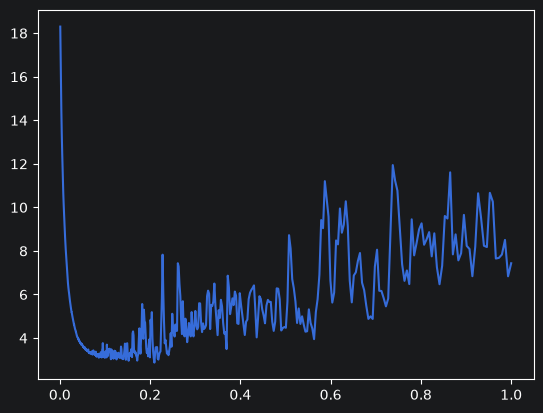

In [73]:
plt.plot(learning_rates, losses)

A good learning rate turns out to be somewhere near the <span style="color:red">valley</span> of this graph.

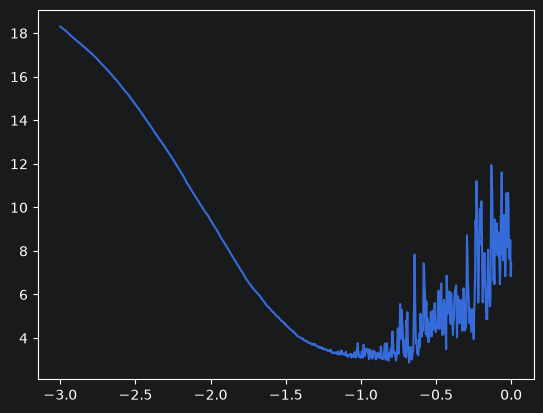

In [74]:
plt.plot(learning_rate_exponents, losses)

#### Learning rate Decay

At the late stage of training (when the loss stabilizes), we can lower the learning rate by 10 times to let the model be closer to the minimum when the training finishes.

In [83]:
minibatch_size = 32
num_step = 40000
num_step_late = 10000
learning_rate = 0.1

M = torch.randn((27,2))
W_hidden = torch.randn((6,100))
b_hidden = torch.randn(100)
W_output = torch.randn((100, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print('Total number of parameters in our MLP:', sum(p.nelement() for p in parameters))

for _ in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

emb_X = M[X]
hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
logits = hidden_out @ W_output + b_output
loss_full = F.cross_entropy(logits, Y)
print('Loss for the full dataset:', loss_full.item())

Total number of parameters in our MLP: 3481
Loss for the full dataset: 2.3618276119232178


In [84]:
for _ in range(num_step_late):
    # minibatch construction:
    ix = torch.randint(0, X.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y[ix])


    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -(0.1 * learning_rate) * p.grad

emb_X = M[X]
hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
logits = hidden_out @ W_output + b_output
loss_full = F.cross_entropy(logits, Y)
print('Loss for the full dataset:', loss_full.item())

Loss for the full dataset: 2.310192823410034


### Spliting the datset into Training / Dev (Validation) / Test set

Typical ratio: 80% / 10% / 10%

Training data is used to tune the parameters of the model;

Dev/Validation set is used to tune the hyperparameters of the model;

Test set is used to evaluate the performance of the end model.

<span style="color:red">Why can't we just use the training set (the full training loss) to tune the hyperparameters?</span>

对训练集拟合最好的那组超参不一定在训练集之外的数据上表现的最好（我们关心的是泛化能力）。

<span style="color:red">Why can't we just use the test set to tune the hyperparameters?</span>

You will overfit the hyperparameters to the finite test set.

In [86]:
def build_dataset(words):
    block_size = 3  # size of the prefix context
    X = []  # inputs
    Y = []  # labels

    for w in words:
        context = [0] * block_size  # [0,0,...,0]
        # Note here that we use the special token '.' for padding
        for ch in w + '.':
            index = str_to_idx[ch]
            X.append(context)
            Y.append(index)
            context = context[1:] + [index]   # roll the window

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [89]:
len(words)

32033

In [93]:
random.shuffle(words)
X_train, Y_train =build_dataset(words[:int(0.8*len(words))])
X_dev, Y_dev =build_dataset(words[int(0.8*len(words)):int(0.9*len(words))])
X_test, Y_test =build_dataset(words[int(0.9*len(words)):])

<span style="color:red">我们这里可不可以按examples分而不按词汇分？会不会导致数据泄漏？</span> (grouped splitting)

In [98]:
X_train

tensor([[ 0,  0,  0],
        [ 0,  0, 18],
        [ 0, 18,  8],
        ...,
        [ 0,  1, 12],
        [ 1, 12,  9],
        [12,  9,  5]])

In [96]:
print(Y_train)
print(len(Y_train))

tensor([18,  8,  9,  ...,  9,  5,  0])
182618


In [101]:
minibatch_size = 32
num_step = 40000
num_step_late = 10000
learning_rate = 0.1

M = torch.randn((27,2))
W_hidden = torch.randn((6,100))
b_hidden = torch.randn(100)
W_output = torch.randn((100, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print('Total number of parameters in our MLP:', sum(p.nelement() for p in parameters))

for _ in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

for _ in range(num_step_late):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -(0.1*learning_rate) * p.grad

with torch.no_grad():

    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_train = F.cross_entropy(logits, Y_train)
    print('Loss for the training set:', loss_train.item())

    emb_X = M[X_dev]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_dev = F.cross_entropy(logits, Y_dev)
    print('Loss for the dev set:', loss_dev.item())

Total number of parameters in our MLP: 3481
Loss for the training set: 2.3062546253204346
Loss for the dev set: 2.3105146884918213


<span style="color:red">仔细理解 Cross Entropy 的含义。尤其地，不同 set of data 上 CE 之间的意义。</span>

CE 相同可以代表：在两个 sets 上分别随机抽足够多的 N 个 examples 让 model 做 next-token prediction，model 全部正确拟合的概率在两个 sets 上是相等的（这是几何平均的含义）。

我现在 roughly 就把 CE 理解成（一个与数据集大小无关的）度量“模型对数据集拟合好坏程度”的一个量。这个好坏程度由于几何平均，比算术平均对拟合出大错的 examples 更敏感。

咱们训练出来的 MLP 在 dev set 上的表现和在 training set 上的表现差不多好，说明没有过拟合。

因此我们可以尝试增大参数量，来让拟合更强（如果增加后仍没有过拟合，we then found a better model）。

### Increase the hidden layer size

In [107]:
hidden_layer_size = 300
minibatch_size = 32
num_step = 30000
num_step_late = 10000
learning_rate = 0.1

M = torch.randn((27,2))
W_hidden = torch.randn((6,hidden_layer_size))
b_hidden = torch.randn(hidden_layer_size)
W_output = torch.randn((hidden_layer_size, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print('Total number of parameters in our MLP:', sum(p.nelement() for p in parameters))

steps = []
losses = []

for i in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

    # This would be too slow!!!
    #with torch.no_grad():
    #    emb_X = M[X_train]
    #    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    #    logits = hidden_out @ W_output + b_output
    #    loss_full = F.cross_entropy(logits, Y_train)

    # track stats:
    steps.append(i)
    losses.append(loss_for_minibatch.item())

Total number of parameters in our MLP: 10281


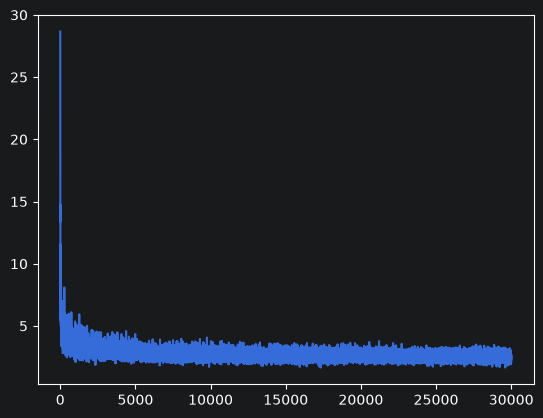

In [108]:
plt.plot(steps, losses)

Side note: 上面的噪音是因为我们画的是minibatch的losses。每一步的loss是当前full training set loss的无偏估计。

In [114]:
with torch.no_grad():
    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_full = F.cross_entropy(logits, Y_train)
    print('Current loss for the training set:', loss_full.item())

Current loss for the training set: 2.4910314083099365


Let's continue training.

In [115]:
for i in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -learning_rate * p.grad

In [118]:
with torch.no_grad():
    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_full = F.cross_entropy(logits, Y_train)
    print('Current loss for the training set:', loss_full.item())

Current loss for the training set: 2.5011138916015625


In [123]:
for i in range(num_step * 2):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -0.05 * p.grad

In [124]:
with torch.no_grad():
    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_full = F.cross_entropy(logits, Y_train)
    print('Current loss for the training set:', loss_full.item())

Current loss for the training set: 2.324594259262085


In [127]:
for i in range(num_step * 2):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        p.data += -0.01 * p.grad

In [129]:
with torch.no_grad():
    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_train = F.cross_entropy(logits, Y_train)
    print('Loss for the training set:', loss_train.item())

    emb_X = M[X_dev]
    hidden_out = torch.tanh(emb_X.view(-1,6) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_dev = F.cross_entropy(logits, Y_dev)
    print('Loss for the dev set:', loss_dev.item())

Loss for the training set: 2.235990285873413
Loss for the dev set: 2.2465410232543945


Dev set 和 Training set 的 loss 还是差不多，说明没有过拟合。并且 loss 要比扩 hidden layer 前要好了（之前大概是 2.3）。我们确实得到了一个稍微好一点的模型。但没有好很多的原因可能有：

- Embedding space 维度太低（目前是2维的），不足以区分我们目前的vocabulary。
- Batch size 太小，导致 SGD 时噪音太大。
- 模型能看到的 prefix context length 太短，input 信息不够做出可靠预测。

我们现在来可视化一下 embedding space：

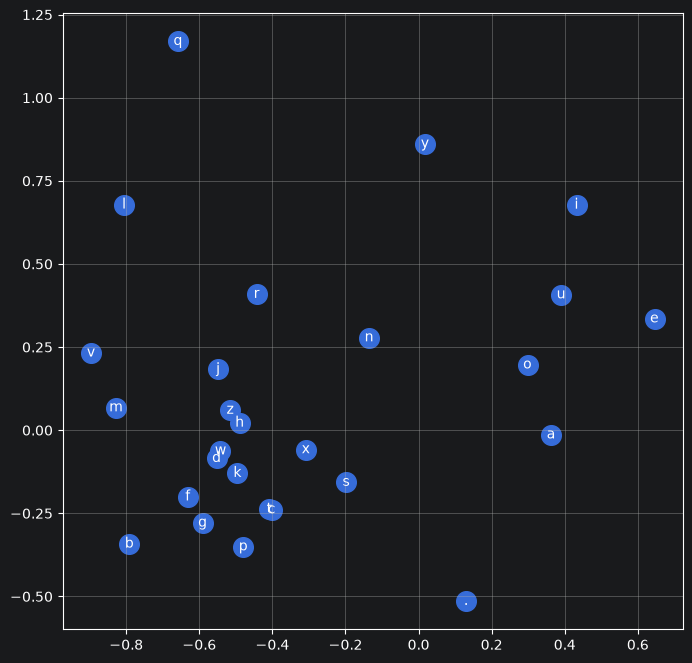

In [131]:
plt.figure(figsize=(8, 8))
plt.scatter(M[:,0].data, M[:,1].data, s=200)
for i in range(M.shape[0]):
    plt.text(M[i,0].item(), M[i,1].item(), idx_to_str[i], ha='center', va='center', color='white')
plt.grid('minor')

我们可以看到一些结构：

- 元音（a/e/i/o/u）聚到了一起：the neural net treats them as interchangeable when using as inputs.
- q/. 的语义和其他 tokens 的语义有明显差别。

### Increase the dimension of the Embeddings

In [133]:
vector_embedding_dim = 10
num_prefix_context_token = 3
num_input = vector_embedding_dim * num_prefix_context_token
hidden_layer_size = 200
minibatch_size = 32
num_step = 200000
learning_rate_early = 0.1
learning_rate_late = 0.1 * learning_rate

M = torch.randn((27,vector_embedding_dim))
W_hidden = torch.randn((num_input,hidden_layer_size))
b_hidden = torch.randn(hidden_layer_size)
W_output = torch.randn((hidden_layer_size, 27))
b_output = torch.randn(27)

parameters = [M, W_hidden, b_hidden, W_output, b_output]
for p in parameters:
    p.requires_grad = True

print('Total number of parameters in our MLP:', sum(p.nelement() for p in parameters))

steps = []
log10losses = []

for i in range(num_step):
    # minibatch construction:
    ix = torch.randint(0, X_train.shape[0], (minibatch_size,))

    # forward pass:
    emb_X = M[X_train[ix]]
    hidden_out = torch.tanh(emb_X.view(-1,num_input) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_for_minibatch = F.cross_entropy(logits, Y_train[ix])

    # backward pass:
    for p in parameters:
        p.grad = None   # each step needs to recalculate the gradients
    loss_for_minibatch.backward()   # calculate the gradients

    # parameters update:
    for p in parameters:
        learning_rate = learning_rate_early if i < 100000 else learning_rate_late
        p.data += -learning_rate * p.grad

    # track stats:
    steps.append(i)
    log10losses.append(loss_for_minibatch.log10().item())

Total number of parameters in our MLP: 11897


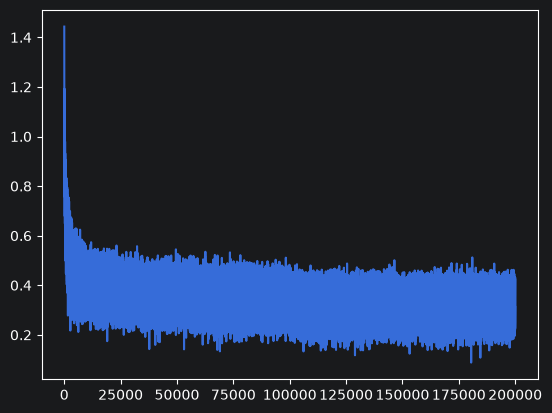

In [134]:
plt.plot(steps, log10losses)

In [136]:
with torch.no_grad():
    emb_X = M[X_train]
    hidden_out = torch.tanh(emb_X.view(-1,num_input) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_train = F.cross_entropy(logits, Y_train)
    print('Loss for the training set:', loss_train.item())

    emb_X = M[X_dev]
    hidden_out = torch.tanh(emb_X.view(-1,num_input) @ W_hidden + b_hidden)
    logits = hidden_out @ W_output + b_output
    loss_dev = F.cross_entropy(logits, Y_dev)
    print('Loss for the dev set:', loss_dev.item())

Loss for the training set: 2.1082780361175537
Loss for the dev set: 2.1551263332366943


Note that the dev set loss starts becoming higher than the training set loss.

### Sampling from the MLP

In [142]:
context = [0] * 3
context

[0, 0, 0]

In [140]:
torch.tensor(context)

tensor([0, 0, 0])

In [141]:
M

tensor([[ 6.6794e-01, -4.0402e-01,  4.0161e-01,  2.7102e-01,  2.9373e-01,
          4.6586e-01, -8.5101e-01, -1.9024e-01,  1.2959e+00,  3.9393e-01],
        [ 3.1953e-01, -1.0973e-01,  2.0589e-01, -6.0884e-01,  1.6706e-01,
         -5.7195e-01,  9.3027e-02, -6.5192e-02,  5.1677e-01, -5.5505e-01],
        [-1.1507e-01, -7.1756e-01,  4.6535e-01,  3.2730e-01,  2.1071e-01,
          1.0244e-01,  1.2825e-01, -8.2282e-01, -1.3107e-01,  8.9562e-01],
        [-4.0611e-01, -3.5453e-01,  1.0481e-01,  5.7941e-01,  2.8555e-01,
         -2.4164e-01, -3.5071e-01, -1.2174e+00,  3.2882e-01,  1.6012e+00],
        [ 2.4637e-02, -8.9844e-03, -1.0223e-01,  1.8726e-01, -9.3478e-02,
         -2.5168e-01,  2.4091e-01, -4.0330e-01,  1.4142e-01,  2.1555e-01],
        [ 2.6434e-01, -3.1672e-01, -7.1364e-02, -8.1233e-01,  1.1238e-01,
         -1.4208e-01,  1.1432e-02,  2.3517e-01,  1.9114e-01, -1.8925e-01],
        [ 3.7649e-01, -2.2261e-01,  2.0303e-01,  1.1692e-03,  6.1895e-01,
          3.0971e-01,  1.4086e-0

In [143]:
M[torch.tensor(context)]

tensor([[ 0.6679, -0.4040,  0.4016,  0.2710,  0.2937,  0.4659, -0.8510, -0.1902,
          1.2959,  0.3939],
        [ 0.6679, -0.4040,  0.4016,  0.2710,  0.2937,  0.4659, -0.8510, -0.1902,
          1.2959,  0.3939],
        [ 0.6679, -0.4040,  0.4016,  0.2710,  0.2937,  0.4659, -0.8510, -0.1902,
          1.2959,  0.3939]], grad_fn=<IndexBackward0>)

In [144]:
M[torch.tensor(context)].view(1,-1)

tensor([[ 0.6679, -0.4040,  0.4016,  0.2710,  0.2937,  0.4659, -0.8510, -0.1902,
          1.2959,  0.3939,  0.6679, -0.4040,  0.4016,  0.2710,  0.2937,  0.4659,
         -0.8510, -0.1902,  1.2959,  0.3939,  0.6679, -0.4040,  0.4016,  0.2710,
          0.2937,  0.4659, -0.8510, -0.1902,  1.2959,  0.3939]],
       grad_fn=<ViewBackward0>)

In [149]:
demo = True
num_samples = 20
prefix_context_window = 3

for _ in range(num_samples):
    output_tokens = []
    prefix_context = [0] * prefix_context_window
    while True:
        embeddings = M[torch.tensor(prefix_context)]
        hidden_layer_output = torch.tanh(embeddings.view(1,-1) @ W_hidden + b_hidden)
        print('dimension of hidden layer outputs:', hidden_layer_output.shape) if demo else None
        logits = hidden_layer_output @ W_output + b_output
        print('dimension of logits:', logits.shape) if demo else None
        probs = F.softmax(logits, dim=1)
        print('dimension of the probability distribution after softmax:',probs.shape) if demo else None
        index = torch.multinomial(probs, num_samples=1).item()
        prefix_context = prefix_context[1:] + [index]
        output_tokens.append(index)
        print('---' * 10) if demo else None
        demo = False
        if index == 0:
            break
    print(''.join(idx_to_str[index] for index in output_tokens))

dimension of hidden layer outputs: torch.Size([1, 200])
dimension of logits: torch.Size([1, 27])
dimension of the probability distribution after softmax: torch.Size([1, 27])
------------------------------
arizara.
ran.
miline.
rone.
maryana.
faona.
ilena.
myreffernelle.
abrian.
jako.
jenito.
flwo.
tzelynn.
aloy.
seen.
madyn.
marvinxa.
oluwamerka.
remen.
ashord.
